<a href="https://colab.research.google.com/github/rakshitha01-a11y/house-price-prediction/blob/main/Copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("House Price Prediction Dataset.csv")
df.head()

Saving House Price Prediction Dataset.csv to House Price Prediction Dataset (1).csv


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [ ]:
df = pd.read_csv("House Price Prediction Dataset.csv")

In [ ]:
df = df.dropna()
num_cols = ['sqft_living', 'bedrooms', 'bathrooms', 'years_old']
cat_cols = ['neighborhood', 'has_garden']
num_cols = ['Area', 'Bedrooms', 'Bathrooms', 'YearBuilt']
cat_cols = ['Location', 'Condition', 'Garage']
X = df[num_cols + cat_cols].copy()
y = df['Price']

In [ ]:
X = df[num_cols + cat_cols].copy()
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])
X = pd.get_dummies(X, columns=cat_cols)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
def evaluate(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"\n--- {name} Results ---")
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"R2 Score (Accuracy): {r2:.4f}")
    print(f"Mean Absolute Error: {mae:.2f}")

evaluate("Linear Regression", y_test, lr_pred)
evaluate("Random Forest", y_test, rf_pred)
evaluate("Gradient Boosting", y_test, gb_pred)


--- Linear Regression Results ---
Mean Squared Error: 78103848486.62
R2 Score (Accuracy): -0.0039
Mean Absolute Error: 242757.12

--- Random Forest Results ---
Mean Squared Error: 87504730980.26
R2 Score (Accuracy): -0.1248
Mean Absolute Error: 255207.67

--- Gradient Boosting Results ---
Mean Squared Error: 81200435577.82
R2 Score (Accuracy): -0.0437
Mean Absolute Error: 246987.34


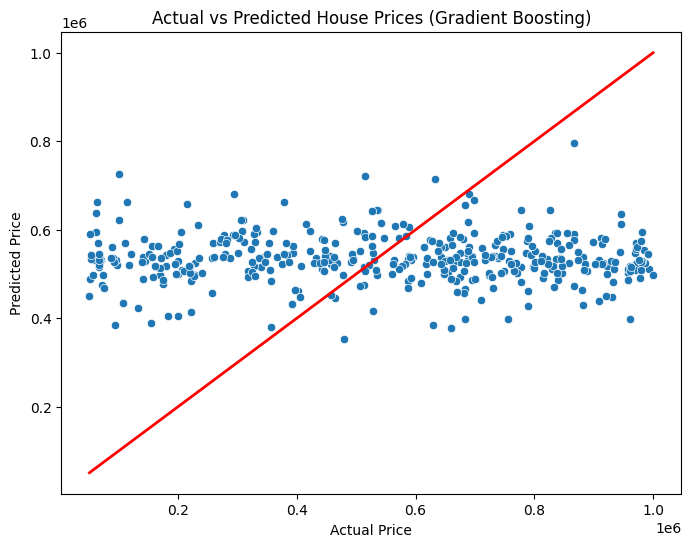

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=gb_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices (Gradient Boosting)")
plt.show()